# CMI and Markov length for ring of Fibonacci plaquettes

Calculating CMI with density matrices 

\begin{equation}

CMI = I(A:C|B) = S(AB) + S(BC) - S(ABC) - S(B),

\end{equation}

where $S(Q)$ is the von Neumann entropy of the $Q$ subsystem:

\begin{equation}

S(Q) = - tr ( \rho_{Q} \log \rho_Q ),

\end{equation}

with

\begin{equation}

\rho_{Q} = tr_{\bar{Q}} (\rho).

\end{equation}

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import math
from functools import reduce
try:
    import scienceplots
except ImportError:
    scienceplots = None
from itertools import combinations
from collections import Counter, defaultdict
from collections.abc import Iterable
from functools import lru_cache
import os

os.makedirs("New_plots", exist_ok=True)


In general, for a row of $k$ Fibonacci plaquettes, the ground state is given by:
\begin{equation}
    \ket{\text{g.s.}}=\frac{1}{D^k}\sum_{i=0}^k\phi^i\left(\sum \frac{1}{\phi^{a}} \frac{1}{(\sqrt{\phi})^{b}}\text{ states with $i$ applied plaquettes}  \right),
\end{equation}
where $a$ is the number of unflipped (black) inner edges and $b$ is the number of flipped (red) inner edges. The ground state is normalized by the factor $D$ (raised to the power of the total number of plaquettes), which is given by:
\begin{equation}
    D = \sqrt{1+\phi},
\end{equation}
and the factor of $\phi$ is the golden ratio:
\begin{equation}
    \phi = \frac{1+\sqrt{5}}{2}.
\end{equation}

A plaquette operator is composed out a product of four Pauli $X$ operators acting on its edges. However, because of the non-trivial fusion rule of Fibonacci anyons:
\begin{equation}
    \tau \times \tau = 1+ \tau,
\end{equation}
an edge that is shared between two plaquette operators will be in superposition of flipped and unflipped bits, with different weights specified in detail by Fibonacci fusion category.

In [2]:
# ============================================================
# Fibonacci code parameters
# ============================================================

# -------------------------
# Golden ratio
# -------------------------
phi = (1+ np.sqrt(5))/2
D = np.sqrt(1+phi**2)

# -------------------------
# Combinatorial helper
# -------------------------
def sublists(k: int, m: int) -> list[list[int]]:
    """
    Return all sublists of length m from [1, 2, ..., k].
    """
    if m < 0 or m > k:
        return []

    return [list(c) for c in combinations(range(1, k + 1), m)]


In [3]:
# -------------------------
# Function finding repeated integers in the total list of edges
# -------------------------
def find_repeated_integers(obj):
    """
    Recursively searches a possibly multidimensional object
    and returns a list of integers that appear more than once.
    """

    def flatten(x):
        if isinstance(x, int):
            yield x
        elif isinstance(x, Iterable) and not isinstance(x, (str, bytes)):
            for item in x:
                yield from flatten(item)

    numbers = list(flatten(obj))
    counts = Counter(numbers)

    return [num for num, count in counts.items() if count > 1]

# -------------------------
# Function generating all subarrays of the given array
# -------------------------

def all_subarrays(arr):
    result = []

    for start in range(len(arr)):
        for end in range(start + 1, len(arr) + 1):
            result.append(arr[start:end])

    return result


In [4]:
# ============================================================
# Memory-optimised ground state and density-matrix helpers
# ============================================================

# The original implementation explicitly built 2^N x 2^N plaquette
# operators and density matrices.  That becomes impossible already at
# N=18.  The code below represents the wavefunction sparsely as
# {basis_integer: amplitude}.  A Pauli-X plaquette simply XORs a bit mask.

ket_0 = np.array([1.0, 0.0])
ket_1 = np.array([0.0, 1.0])
Pauli_X = np.array([[0.0, 1.0], [1.0, 0.0]])
Pauli_Z = np.array([[1.0, 0.0], [0.0, -1.0]])
I = np.eye(2)


def kron_power(v, N):
    """Dense helper retained for small test calculations only."""
    return reduce(np.kron, [v] * N)


def bit_mask(indices):
    """Return an integer mask with bits in `indices` set to 1."""
    mask = 0
    for q in indices:
        mask ^= (1 << int(q))
    return mask


def parity(x):
    """Parity of the number of 1-bits in integer x."""
    return int(x).bit_count() & 1


@lru_cache(maxsize=None)
def plaquette_masks_cached(plaquettes_tuple):
    """Cached integer masks for plaquettes."""
    return tuple(bit_mask(p) for p in plaquettes_tuple)


def canonical_plaquettes(plaquettes):
    """Convert plaquette arrays/lists into a hashable tuple-of-tuples."""
    return tuple(tuple(int(x) for x in p) for p in plaquettes)


def ground_state_sparse(N, plaquettes, number_plaquettes, D=D, phi=phi, normalize=True):
    """
    Build the Fibonacci-ring ground state as a sparse state dictionary.

    Keys are computational-basis integers.  Values are amplitudes.  This
    avoids constructing any 2^N x 2^N plaquette matrices.
    """
    plaquettes_t = canonical_plaquettes(plaquettes)
    p_masks = plaquette_masks_cached(plaquettes_t)

    amps = defaultdict(complex)
    amps[0] += 1.0

    for k in range(1, number_plaquettes + 1):
        for combo in combinations(range(number_plaquettes), k):
            total_edges = [plaquettes_t[h] for h in combo]
            inner_edges = find_repeated_integers(total_edges)

            # Applying all plaquettes corresponds to one XOR mask.
            xmask = 0
            for h in combo:
                xmask ^= p_masks[h]

            base_amp = phi**k

            if inner_edges == []:
                amps[xmask] += base_amp
            else:
                # Toric-code-like term: shared inner edges cancel.
                amps[xmask] += (1 / phi)**len(inner_edges) * base_amp

                # Extra terms from the Fibonacci-inspired fusion rule.
                # This retains the notebook's original all_subarrays rule.
                for edge_list in all_subarrays(inner_edges):
                    extra_mask = bit_mask(edge_list)
                    coeff = ((1 / np.sqrt(phi))**len(edge_list)
                             * (1 / phi)**(len(inner_edges) - len(edge_list)))
                    amps[xmask ^ extra_mask] += coeff * base_amp

    prefactor = 1 / (D**number_plaquettes)
    amps = {b: prefactor * a for b, a in amps.items() if abs(a) > 0}

    if normalize:
        norm = math.sqrt(sum(abs(a)**2 for a in amps.values()))
        amps = {b: a / norm for b, a in amps.items() if abs(a / norm) > 1e-15}

    return amps


def sparse_to_dense_state(amps, N):
    """Convert a sparse state dictionary to a dense vector for small N tests."""
    psi = np.zeros(2**N, dtype=complex)
    for b, a in amps.items():
        psi[b] = a
    return psi


def ground_state(N, plaquettes, number_plaquettes, D=D, phi=phi):
    """Dense wavefunction wrapper, mainly for backwards compatibility/tests."""
    return sparse_to_dense_state(
        ground_state_sparse(N, plaquettes, number_plaquettes, D, phi, normalize=True), N
    )


def rho_0_function(N, plaquettes, number_plaquettes, D=D, phi=phi):
    """
    Dense rho_0 wrapper retained for small N only.

    Do not use this inside the Markov-length loop.  Use ground_state_sparse
    and CMI_from_sparse_state instead.
    """
    psi = ground_state(N, plaquettes, number_plaquettes, D, phi)
    return np.outer(psi, psi.conj())


# Dense local operators retained only for small diagnostic tests.
def local_operator(op, i, N):
    ops = [I] * N
    ops[i] = op
    return reduce(np.kron, ops)


def plaquette_operator(i1, i2, i3, i4, N):
    return (local_operator(Pauli_X, i1, N)
            @ local_operator(Pauli_X, i2, N)
            @ local_operator(Pauli_X, i3, N)
            @ local_operator(Pauli_X, i4, N))


In [5]:
plaquettes_4 = [
        (0, 1, 2, 3),
        (3, 4, 5, 6),
        (6, 7, 8, 9),
        (9, 10, 11, 0),
    ]


In [6]:
# Quick test of the sparse ground state
state_4 = ground_state_sparse(12, plaquettes_4, 4, D=D, phi=phi)
test = sparse_to_dense_state(state_4, 12)
print(test)
print("Number of non-zero amplitudes:", np.count_nonzero(test))
print("Norm:", np.vdot(test, test).real)


[0.08031512+0.j 0.        +0.j 0.        +0.j ... 0.        +0.j
 0.16530225+0.j 0.2102677 +0.j]
Number of non-zero amplitudes: 42
Norm: 1.0000000000000002


In [7]:
# Dense rho_0 is only safe for small N.  For N=12 this is still OK,
# but later cells use sparse states instead of full density matrices.
rho_0 = rho_0_function(12, plaquettes_4, 4, D=D, phi=phi)
print("Density matrix shape:", rho_0.shape)
print("Trace:", np.trace(rho_0).real)
print("Number of non-zero entries:", np.count_nonzero(np.abs(rho_0) > 1e-14))


Density matrix shape: (4096, 4096)
Trace: 1.0000000000000004
Number of non-zero entries: 1764


Subsequantly, we define the noise channel:

\begin{equation}

\mathcal{E}^i_p(\cdot) = (1-p)(\cdot) + pZ_i(\cdot)Z_i

\end{equation}

acting on qubits that are shared between plaquettes. For example, for 12-qubit system with 4 plaquettes, the noise will act on sites $[0,3,6,9]$.

In [8]:
# ============================================================
# Memory-optimised dephasing channel
# ============================================================

# For dephasing on m qubits, the noisy state can be written as a mixture
# over 2^m phase-error patterns:
#
#   rho(p) = sum_E p^|E| (1-p)^(m-|E|) Z_E |psi><psi| Z_E .
#
# We never build rho(p).  Instead, reduced density matrices are accumulated
# directly from these weighted pure-state branches.


def error_patterns(indexlist, p):
    """Yield (error_mask, probability_weight) for dephasing on indexlist."""
    idx = [int(i) for i in indexlist]
    m = len(idx)
    for pattern in range(1 << m):
        mask = 0
        weight = 1.0
        for j, q in enumerate(idx):
            if (pattern >> j) & 1:
                mask ^= (1 << q)
                weight *= p
            else:
                weight *= (1 - p)
        if weight > 0:
            yield mask, weight


def apply_Z_phase_to_sparse_state(amps, zmask):
    """Return amplitudes after applying Z operators represented by zmask."""
    if zmask == 0:
        return amps
    return {b: ((-1) if parity(b & zmask) else 1) * a for b, a in amps.items()}


# Dense functions retained for backwards compatibility on small systems.
def phase_flip_channel(rho, p, i, N):
    Z_i = local_operator(Pauli_Z, i, N)
    return (1 - p) * rho + p * (Z_i @ rho @ Z_i)


def noise_channel(rho_0, p, N, indexlist):
    rho = rho_0
    for i in indexlist:
        rho = phase_flip_channel(rho, p, i, N)
    return rho


Now, we will define functions to caluclate von Neuman entropies of the whole matrix and the reduced density matrices to subsequently calculate CMI. 

In [9]:
# ============================================================
# Memory-optimised reduced states, entropies, and CMI
# ============================================================


def von_neumann_entropy(rho, tol=1e-12):
    """Compute S(rho) = -Tr rho log2 rho."""
    rho = np.asarray(rho)
    if np.max(np.abs(np.imag(rho))) < 1e-14:
        rho = np.real(rho)
        rho = 0.5 * (rho + rho.T)
    else:
        rho = 0.5 * (rho + rho.conj().T)  # remove tiny numerical non-Hermiticity
    eigvals = np.linalg.eigvalsh(rho)
    eigvals = eigvals[eigvals > tol]
    return float(-np.sum(eigvals * np.log2(eigvals)))


def compress_bits(x, positions):
    """Extract bits of x at `positions` into a compact integer."""
    y = 0
    for out_pos, q in enumerate(positions):
        y |= ((int(x) >> int(q)) & 1) << out_pos
    return y


def reduced_density_from_sparse_pure_compact(amps, keep, N):
    """
    Reduced density matrix of a sparse pure state without forming full rho.

    The returned matrix is compact: it only contains kept-basis states that
    actually occur in the sparse wavefunction.  Missing rows/columns would be
    exactly zero and do not affect the entropy.

    Returns
    -------
    rho_compact : ndarray
        Reduced density matrix on the occupied kept basis.
    labels : list[int]
        The original compressed kept-basis label for each compact row/column.
    """
    keep = tuple(sorted(set(int(q) for q in keep)))
    trace = tuple(q for q in range(N) if q not in keep)

    grouped = defaultdict(list)
    occupied = set()
    for basis, amp in amps.items():
        k_idx = compress_bits(basis, keep)
        e_idx = compress_bits(basis, trace)
        grouped[e_idx].append((k_idx, amp))
        occupied.add(k_idx)

    labels = sorted(occupied)
    label_to_pos = {lab: pos for pos, lab in enumerate(labels)}
    rho = np.zeros((len(labels), len(labels)), dtype=float)

    for entries in grouped.values():
        for i_lab, ai in entries:
            i = label_to_pos[i_lab]
            for j_lab, aj in entries:
                j = label_to_pos[j_lab]
                rho[i, j] += float(np.real(ai * np.conj(aj)))

    return rho, labels


def dephase_reduced_density_compact(rho_pure, labels, keep, indexlist, p):
    """
    Apply dephasing to an already reduced density matrix.

    For a matrix element |x><y|, each noisy qubit retained in `keep` gives a
    factor 1 if x_q=y_q and (1-2p) if x_q != y_q.  Noisy qubits that have been
    traced out do not affect the reduced state.
    """
    keep = tuple(sorted(set(int(q) for q in keep)))
    noisy_positions = [keep.index(int(q)) for q in indexlist if int(q) in keep]

    if len(noisy_positions) == 0:
        rho = rho_pure.copy()
    else:
        lam = 1 - 2 * p
        rho = rho_pure.copy()
        for a, x in enumerate(labels):
            for b, y in enumerate(labels):
                diff = 0
                z = x ^ y
                for pos in noisy_positions:
                    diff += (z >> pos) & 1
                if diff:
                    rho[a, b] *= lam**diff

    tr = np.trace(rho).real
    if tr > 0:
        rho /= tr
    return rho


def reduced_density_after_dephasing(amps, keep, N, indexlist, p):
    rho_pure, labels = reduced_density_from_sparse_pure_compact(amps, keep, N)
    return dephase_reduced_density_compact(rho_pure, labels, keep, indexlist, p)


def entropy_after_dephasing(amps, keep, N, indexlist, p, cache=None):
    """Entropy of a dephased reduced state, with optional pure-rho cache."""
    keep_key = tuple(sorted(set(int(q) for q in keep)))
    if cache is not None and keep_key in cache:
        rho_pure, labels = cache[keep_key]
    else:
        rho_pure, labels = reduced_density_from_sparse_pure_compact(amps, keep_key, N)
        if cache is not None:
            cache[keep_key] = (rho_pure, labels)
    rho = dephase_reduced_density_compact(rho_pure, labels, keep_key, indexlist, p)
    return von_neumann_entropy(rho)


def CMI_from_sparse_state(p, indexlist, amps, A, B, C, N, cache=None):
    """Compute I(A:C|B) without constructing the full noisy density matrix."""
    AB = sorted(set(A + B))
    BC = sorted(set(B + C))
    B_only = sorted(set(B))
    ABC = sorted(set(A + B + C))

    S_AB = entropy_after_dephasing(amps, AB, N, indexlist, p, cache=cache)
    S_BC = entropy_after_dephasing(amps, BC, N, indexlist, p, cache=cache)
    S_B = entropy_after_dephasing(amps, B_only, N, indexlist, p, cache=cache)
    S_ABC = entropy_after_dephasing(amps, ABC, N, indexlist, p, cache=cache)

    return S_AB + S_BC - S_B - S_ABC


# Original dense partial trace retained for validation on small systems only.
def partial_trace(rho, keep, N):
    keep = sorted(set(keep))
    trace_out = [q for q in range(N) if q not in keep]
    rho_tensor = rho.reshape([2] * N + [2] * N)
    current_N = N
    for q in sorted(trace_out, reverse=True):
        rho_tensor = np.trace(rho_tensor, axis1=q, axis2=q + current_N)
        current_N -= 1
    dim_keep = 2 ** len(keep)
    return rho_tensor.reshape(dim_keep, dim_keep)


def CMI(p, indexlist, rho_0_or_state, A, B, C, N):
    """
    Backwards-compatible CMI wrapper.

    If rho_0_or_state is a sparse state dictionary, use the optimized path.
    If it is a dense matrix, use the original dense path.
    """
    if isinstance(rho_0_or_state, dict):
        return CMI_from_sparse_state(p, indexlist, rho_0_or_state, A, B, C, N)

    rho = noise_channel(rho_0_or_state, p, N, indexlist)
    AB = sorted(set(A + B))
    BC = sorted(set(B + C))
    B_only = sorted(set(B))
    ABC = sorted(set(A + B + C))
    return (von_neumann_entropy(partial_trace(rho, AB, N))
            + von_neumann_entropy(partial_trace(rho, BC, N))
            - von_neumann_entropy(partial_trace(rho, B_only, N))
            - von_neumann_entropy(partial_trace(rho, ABC, N)))


The first partition into the regions that we are interested in for 12 qubits is given by:

\begin{align}

&A = [1,2]\\

&B = [3,4,5,5,9,10,11,0]\\

&C = [7,8],

\end{align}

where we considered that some edges will be shared between plaquettes and we don't want to trace theut fully

We considered the indexing of qubits staring from 0 to match the Python syntax. Subsequently, we compute CMI for this region partition.

In [10]:
# ============================================================
# Computation of CMI
# ============================================================

A = [1, 2]
B = [3, 4, 5, 6, 9, 10, 11, 0]
C = [7, 8]
indexlist_4 = [0, 3, 6, 9]

p_array = np.linspace(0.001, 0.999, 40)
cmi_array = np.zeros(len(p_array))

# Use the sparse pure ground state, not rho_0.
state_4 = ground_state_sparse(12, plaquettes_4, 4, D=D, phi=phi)
reduced_cache_4 = {}

for i, p in enumerate(p_array):
    cmi_array[i] = CMI_from_sparse_state(p, indexlist_4, state_4, A=A, B=B, C=C, N=12, cache=reduced_cache_4)

print(cmi_array)


[0.01369206 0.04363659 0.07404733 0.10521524 0.13657598 0.1676136
 0.1978919  0.22704505 0.25476643 0.28079964 0.30493189 0.32698894
 0.34683098 0.36434904 0.3794615  0.39211038 0.4022574  0.40987967
 0.41496521 0.41750883 0.41750883 0.41496521 0.40987967 0.4022574
 0.39211038 0.3794615  0.36434904 0.34683098 0.32698894 0.30493189
 0.28079964 0.25476643 0.22704505 0.1978919  0.1676136  0.13657598
 0.10521524 0.07404733 0.04363659 0.01369206]


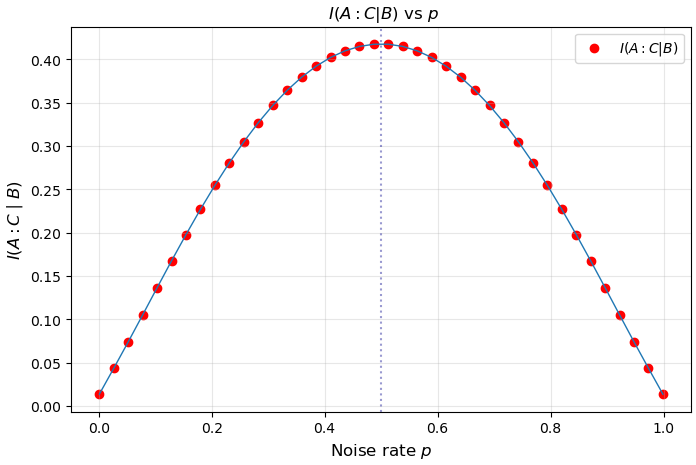

In [11]:
# ============================================================
# Plot of the results of CMI vs noise rate p
# ============================================================


fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(p_array, cmi_array,lw=1)
ax.scatter(p_array, cmi_array,color='red', label=r'$I(A{:}C|B)$')
ax.axvline(0.5, color='darkblue', ls=':', alpha=0.4)
ax.set_xlabel(r'Noise rate $p$', fontsize=12)
ax.set_ylabel(r'$I(A{:}C \mid B)$ ', fontsize=12)
ax.set_title(r' $I(A{:}C|B)$ vs $p$', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

try:
    plt.style.use('science')
except OSError:
    pass
plt.savefig("New_plots/CMI_vs_p_fib_ring.png", dpi=300)
plt.show()


The results presented above were computed for 12 qubits, with the partition into regions A,B,C given by: $A = [1,2], B = [3,4,5,6,9,10,11,0],$ and $C = [7,8].$ However, to compute Markov length, we need to repeat the calculation above for different system sizes $r$, where $r$ is the number of plaquettes separating region A from region C. For instance, for the calculation above, $r=1$, because region $B$ encloses region $A$ like a one-dimensional ring. 

Subsequently, we know that CMI should satisfy the following bound with finite Markov length $\xi = \xi(p)$ as long as the system stays in one-phase of matter:
\begin{equation}
I(A:C \mid B)
\leq a e^{-r/\xi(p)} + c_0,
\end{equation}
where $a$ is a proportionality constant (for constatnt size of regions $A$ and $C$) and $c_0$ is a vertical offset, signifying the minimal value to which the CMI function will be converging for incresing system sizes (which is shown in the following plots). In particular, for our system, $c_0 =0$, as observed on the plot above. 

Then, it is possible to compute $\xi = \xi(p)$ considering:
\begin{equation}
\ln(I(A:C \mid B)) = -\frac{1}{\xi(p)} + \ln{a},
\end{equation}
Therfore, for each noise rate $p$, we can compute CMI for differnt system sizes $r$, and then compute $\xi$ by fitting a linear function to the logarithm of CMI (minus offset) versus $r$, and taking the negative inverse of the slope. This computation was executed below.

In [29]:
# -------------------------
# Noise rates used to evaluate Markov length
# -------------------------
p_array2 = np.linspace(0.001,0.999,40)


In [30]:
# -------------------------
# Function returning plquette indices for given number of plaquettes
# -------------------------

def get_plaquettes(number_of_plaquettes):
    indices = []
    for n in range(number_of_plaquettes):
        indices.append([(0+3*n)%(number_of_plaquettes*3),(1+3*n)%(number_of_plaquettes*3),(2+3*n)%(number_of_plaquettes*3),(3+3*n)%(number_of_plaquettes*3)])
    return np.array(indices)

print(get_plaquettes(4))


[[ 0  1  2  3]
 [ 3  4  5  6]
 [ 6  7  8  9]
 [ 9 10 11  0]]


In [31]:
# -------------------------
# Function returning error indices for given number of qubits in the system 
# -------------------------

def get_error_index(total_system_size):
    indices = []
    for i in range(total_system_size):
        if i%3 == 0:
            indices.append(i)
    return np.array(indices)

print(get_error_index(12))


[0 3 6 9]


In [40]:
# ============================================================
# Defining function computing Markov length
# ============================================================

def fit_markov_length_offset(distances, cmi_values, offset=0.0, threshold=1e-12):
    """
    Fit CMI(r) - offset = a exp(-r / xi).
    """
    distances = np.array(distances)
    cmi_values = np.array(cmi_values)
    shifted = cmi_values - offset
    mask = shifted > threshold

    if np.sum(mask) < 2:
        return np.nan

    x = distances[mask]
    y = np.log(shifted[mask])
    slope, intercept = np.polyfit(x, y, 1)

    if slope >= 0:
        return np.nan
    return -1.0 / slope


# ------------------------------------------------------------
# Define distance-dependent partitions
# ------------------------------------------------------------

R_max = 3
# You can now raise R_max further. Runtime grows with sparse-state support and
# compact reduced-matrix rank, but memory no longer scales as 4^N.
distances = np.arange(1, R_max + 1)

# ------------------------------------------------------------
# Computing CMI matrix
# ------------------------------------------------------------

cmi_matrix = np.zeros((len(p_array2), len(distances)))

# Cache the sparse ground states and reduced pure matrices because the same
# system sizes/partitions are reused for every p.
state_cache = {}
reduced_cache_by_distance = {}

for idd, d in enumerate(distances):
    A_d = list(range(1, 3))
    B_d = list(range(0, 1)) + list(range(3, 3 + d * 3 + 1)) + list(range(3 + d * 3 + 3, 3 + d * 3 + 3 + d * 3))
    C_d = list(range(3 + d * 3 + 1, 3 + d * 3 + 3))

    system_size = len(set(A_d + B_d + C_d))
    nb_plaquettes = int(system_size / 3)
    plaquettes_d = get_plaquettes(nb_plaquettes)
    errorindexlist = get_error_index(system_size)

    if system_size not in state_cache:
        state_cache[system_size] = ground_state_sparse(system_size, plaquettes_d, nb_plaquettes, D=D, phi=phi)
        print(f"Built sparse state for N={system_size}, plaquettes={nb_plaquettes}, support={len(state_cache[system_size])}")

    amps_d = state_cache[system_size]
    reduced_cache = reduced_cache_by_distance.setdefault(d, {})

    for ip, p in enumerate(p_array2):
        cmi_matrix[ip, idd] = CMI_from_sparse_state(
            p, errorindexlist, amps_d, A=A_d, B=B_d, C=C_d, N=system_size, cache=reduced_cache
        )


# ============================================================
# Running function computing Markov length for every p
# ============================================================
xi_array = np.array([
    fit_markov_length_offset(distances, cmi_matrix[ip], offset=0.0)
    for ip in range(len(p_array2))
])


Built sparse state for N=12, plaquettes=4, support=42
Built sparse state for N=18, plaquettes=6, support=244
Built sparse state for N=24, plaquettes=8, support=1344


In [41]:
# ------------------------------------------------------------
# Printing output of the computation
# ------------------------------------------------------------

print("xi_array:")
print(xi_array)
print("finite xi values:", np.sum(np.isfinite(xi_array)))


xi_array:
[0.64172889 0.64096098 0.72182903 0.81066636 0.9012364  0.99323357
 1.08722131 1.18379544 1.28338325 1.38615383 1.49193444 1.60010864
 1.70949419 1.81821233 1.92357624 2.02204761 2.109331   2.18068144
 2.23146558 2.25792089 2.25792089 2.23146558 2.18068144 2.109331
 2.02204761 1.92357624 1.81821233 1.70949419 1.60010864 1.49193444
 1.38615383 1.28338325 1.18379544 1.08722131 0.99323357 0.9012364
 0.81066636 0.72182903 0.64096098 0.64172889]
finite xi values: 40


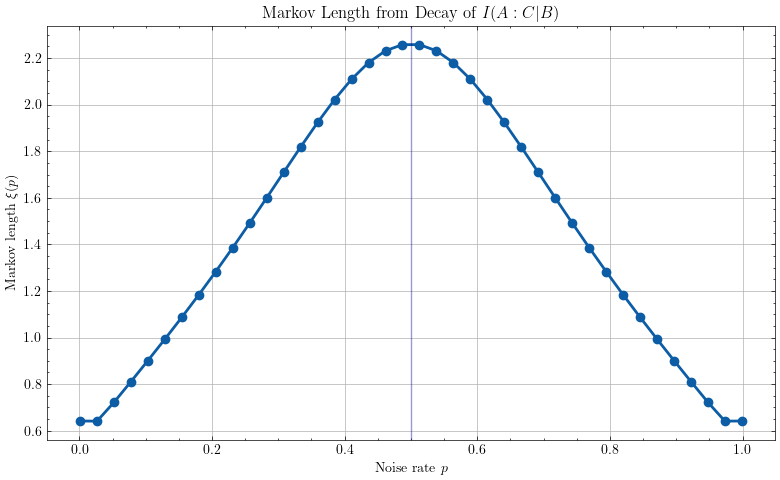

In [42]:
# ============================================================
# Plot xi(p) vs p
# ============================================================

valid = np.isfinite(xi_array)


try:
    plt.style.use('science')
except OSError:
    pass
plt.figure(figsize=(8, 5))

plt.plot(p_array2,xi_array, marker='o',lw=2)
plt.axvline(0.5, color='darkblue', ls='-', alpha=0.4)
plt.xlabel(r"Noise rate $p$")
plt.ylabel(r"Markov length $\xi (p)$")
plt.title(r"Markov Length from Decay of $I(A:C|B)$")
plt.tight_layout()
plt.grid(True)
plt.savefig("New_plots/Xi_vs_p_fib_ring.png", dpi=300)
plt.show()


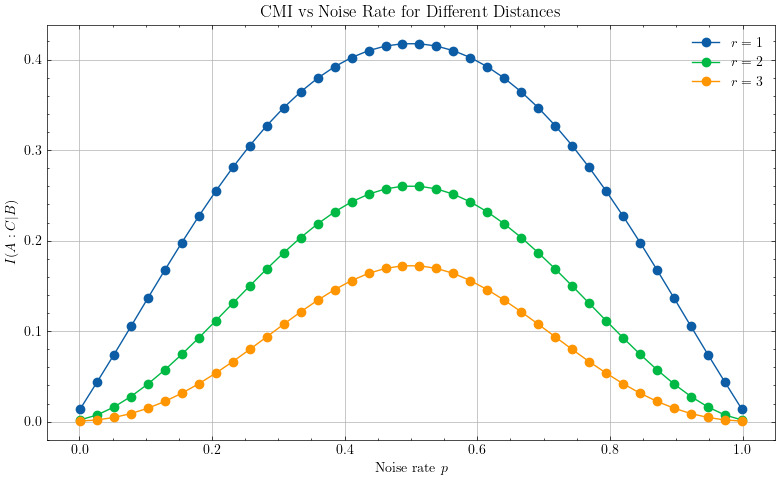

In [43]:
# ============================================================
# CMI vs noise rate p for different distances r
# ============================================================



try:
    plt.style.use('science')
except OSError:
    pass
plt.figure(figsize=(8,5))

for r in distances:
    plt.plot(p_array2,cmi_matrix[:, r-1],marker='o',label=fr"$r={r}$")

plt.xlabel("Noise rate $p$")
plt.ylabel(r"$I(A:C|B)$")
plt.title("CMI vs Noise Rate for Different Distances")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("New_plots/CMI_vs_p_differnt_r_fib_ring.png", dpi=300)
plt.show()


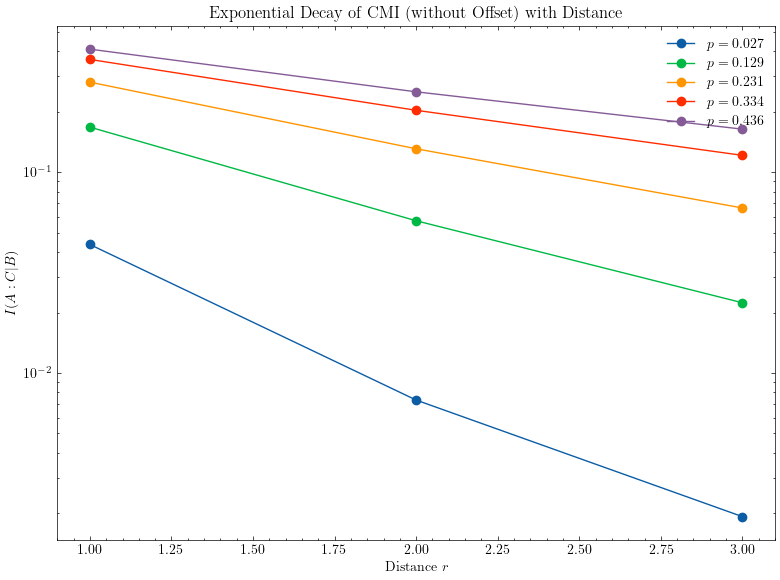

In [44]:
# ============================================================
# CMI vs distance r for different noise rates p
# ============================================================

plt.figure(figsize=(8,6))

try:
    plt.style.use('science')
except OSError:
    pass


for idx in range(1,20,4):

    plt.plot(distances,cmi_matrix[idx],marker='o',label=fr"$p={p_array2[idx]:.3f}$")

plt.yscale('log')

plt.xlabel("Distance $r$")
plt.ylabel(r"$I(A:C|B)$")
plt.title("Exponential Decay of CMI (without Offset) with Distance")
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("New_plots/CMI_decay_with_r_fib_ring.png", dpi=300)
plt.show()
